<a href="https://colab.research.google.com/github/mttomar/big-data-analytics/blob/main/amazon_pagerank_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Identifying Influential Products in a Large-Scale Amazon Network Using PageRank

## Project Overview

For this project, we analyze the Amazon co-purchase network to figure out which products are actually influential in the network. Each node represents a product and edges represent products that are commonly bought together. Since the dataset is large (over 262k nodes and 1.2M edges), we use a sampled graph of 50,000 edges for testing. We use the PageRank algorithm to measure importance based on how influence flows through the network, not just how many connections a node has. We then compare the results with in-degree centrality to see how the rankings differ.

## Dataset Description

We use the Amazon0302 dataset from the Stanford SNAP repository. It is an edge list where each line represents a connection between two products. Lines starting with # are comments and are ignored when loading the data. The dataset contains about 262,111 nodes and 1,234,877 edges, making it a large graph that is suitable for network analysis.

## Loading the Dataset

We read the dataset line by line and build the graph using two structures: one for outgoing edges and one for incoming edges. We skip comment lines and store each connection. After loading, we verify the results by printing the total number of nodes and edges. The values match the dataset description, confirming the graph was built correctly.

In [ ]:
import os
import urllib.request

file_path = "Amazon0302.txt"

# check if dataset already exists so we don’t download it again every time
if not os.path.exists(file_path):
    print("Downloading dataset...")
    url = "https://snap.stanford.edu/data/amazon0302.txt.gz"
    urllib.request.urlretrieve(url, "amazon0302.txt.gz")

    import gzip
    # unzip the downloaded file so we can read it as a normal text file
    with gzip.open("amazon0302.txt.gz", "rb") as f_in:
        with open(file_path, "wb") as f_out:
            f_out.write(f_in.read())

    print("Download complete.")
else:
    print("Dataset already exists.")


from collections import defaultdict

# using dictionaries to store outgoing and incoming edges for each node
out_edges = defaultdict(list)
in_edges = defaultdict(list)
nodes = set()

# read file line by line and build the graph
with open(file_path, "r") as f:
    for line in f:
        # skip comment lines that start with #
        if line.startswith("#"):
            continue

        # each line has two product IDs (edge)
        a, b = map(int, line.split())

        # store outgoing and incoming connections
        out_edges[a].append(b)
        in_edges[b].append(a)

        # keep track of all unique nodes
        nodes.add(a)
        nodes.add(b)

# print basic info to make sure everything loaded correctly
print("Number of nodes:", len(nodes))
print("Number of edges:", sum(len(v) for v in out_edges.values()))

Download complete.
Number of nodes: 262111
Number of edges: 1234877


## Basic Network Statistics

Before running PageRank, we look at some basic properties of the graph. The average out-degree is about 4.71, meaning each node connects to around 4–5 others. The top out-degree nodes all have similar values, but the in-degree distribution is very uneven. Some nodes like 14949 and 4429 have very high in-degree, which shows that a few products are much more connected than others.

In [ ]:
# average out-degree
avg_out_degree = sum(len(out_edges[node]) for node in nodes) / len(nodes)
print("Average out-degree:", avg_out_degree)

# top out-degree nodes
top_out = sorted(out_edges.items(), key=lambda x: len(x[1]), reverse=True)[:10]
print("Top nodes by out-degree:")
for node, edges in top_out:
    print(node, len(edges))

# top in-degree nodes
top_in = sorted(in_edges.items(), key=lambda x: len(x[1]), reverse=True)[:10]

print("\nTop nodes by in-degree")

for node, edges in top_in:
    print(f"{node:<6} -> {len(edges)}")

Average out-degree: 4.711274994181855
Top nodes by out-degree:
0 5
1 5
2 5
3 5
4 5
5 5
6 5
7 5
8 5
10 5

Top nodes by in-degree
14949  -> 420
4429   -> 404
33     -> 361
10519  -> 334
12771  -> 330
8      -> 293
297    -> 280
481    -> 275
5737   -> 272
9106   -> 227


## Creating a Sample Subgraph

Since the full dataset is large, we create a smaller sample of 50,000 edges to speed up testing.

In [ ]:
from collections import defaultdict
import random

# collect all edges from the full graph
all_edges = []
for u in nodes:
    for v in out_edges.get(u, []):
        all_edges.append((u, v))

# sample 50,000 edges
num_sample_edges = 50000
if len(all_edges) < num_sample_edges:
    num_sample_edges = len(all_edges)  # just in case total edges are less

sample_edges = random.sample(all_edges, num_sample_edges)

out_sample = defaultdict(list)
in_sample = defaultdict(list)
nodes_sample = set()

# build sampled graph
for a, b in sample_edges:
    out_sample[a].append(b)
    in_sample[b].append(a)

    nodes_sample.add(a)
    nodes_sample.add(b)

print("Sample nodes:", len(nodes_sample))
print("Sample edges:", len(sample_edges))

Sample nodes: 81071
Sample edges: 50000


Because the sample is created randomly, the exact number of nodes in the sampled graph may vary each time the notebook is run. However, it still preserves the general structure of the network and allows us to test the algorithm efficiently.

## Handling Dangling Nodes

Some nodes have no outgoing edges, which are called dangling nodes.


In [ ]:
# find nodes with no outgoing edges
dangling_nodes = [n for n in nodes_sample if len(out_sample[n]) == 0]

print("Number of dangling nodes:", len(dangling_nodes))

Number of dangling nodes: 34807


The number of dangling nodes depends on the sampled graph and will change slightly with each run. These nodes are handled in the PageRank implementation by redistributing their rank across all nodes to maintain stability.

## PageRank Algorithm Explanation

PageRank measures how important a node is based on its connections. Instead of just counting links, it also considers how important the connected nodes are. The algorithm runs iteratively, updating scores based on incoming connections and a damping factor (usually 0.85). This continues until the values stop changing significantly.

## Implementing PageRank

To compute node importance, we implement PageRank using an iterative approach. Each node starts with an equal rank, and during each iteration, the scores are updated based on incoming connections. We also handle dangling nodes by redistributing their rank evenly across all nodes, which ensures stability in the computation. We track convergence by measuring how much the rank values change between iterations and print this difference at each step. Once the change becomes very small, the algorithm stops.

In [ ]:
def pagerank(out_edges, in_edges, nodes, d=0.85, max_iter=50, tol=1e-6):

    N = len(nodes)

    # initialize ranks
    pr = {node: 1.0 / N for node in nodes}

    for iteration in range(max_iter):
        new_pr = {}

        for node in nodes:
            incoming_sum = 0.0

            # contributions from incoming nodes
            for neighbor in in_edges[node]:
                out_degree = len(out_edges[neighbor])

                if out_degree > 0:
                    incoming_sum += pr[neighbor] / out_degree
                else:
                    # distribute rank evenly if no outgoing edges
                    incoming_sum += pr[neighbor] / N

            new_pr[node] = (1 - d) / N + d * incoming_sum

        # check convergence
        diff = sum(abs(new_pr[node] - pr[node]) for node in nodes)

        print(f"Iteration {iteration+1}, diff = {diff}")

        pr = new_pr

        if diff < tol:
            break

    return pr

## Running PageRank on Sample Graph

We run PageRank on the sampled graph and track how the values change.

In [ ]:
# run PageRank on the sampled graph
pr_scores = pagerank(out_sample, in_sample, nodes_sample)

Iteration 1, diff = 0.499330833466961
Iteration 2, diff = 0.35234994120380075
Iteration 3, diff = 0.04989393706168392
Iteration 4, diff = 0.00833995627675124
Iteration 5, diff = 0.0026278222266636294
Iteration 6, diff = 0.0015934266673884832
Iteration 7, diff = 0.0012647046132031148
Iteration 8, diff = 0.0010141230979691593
Iteration 9, diff = 0.0008401023431439635
Iteration 10, diff = 0.0006996676257808179
Iteration 11, diff = 0.0005877567434004524
Iteration 12, diff = 0.0004938099611399534
Iteration 13, diff = 0.0004173102273177177
Iteration 14, diff = 0.00035251705619819833
Iteration 15, diff = 0.0002988732038452481
Iteration 16, diff = 0.00025327873811283546
Iteration 17, diff = 0.00021485347458793371
Iteration 18, diff = 0.00018238611172255825
Iteration 19, diff = 0.00015489804614302857
Iteration 20, diff = 0.0001315263952855667
Iteration 21, diff = 0.00011174244937468594
Iteration 22, diff = 9.494839986179363e-05
Iteration 23, diff = 8.068108075555952e-05
Iteration 24, diff = 6.8

The difference between iterations starts relatively large and steadily decreases to a very small value, showing that the algorithm converges properly.

## PageRank Results and Top Ranked Nodes

After running PageRank, we sort the nodes by their scores to identify the most influential ones.


In [ ]:
# get top 10 nodes by PageRank score
top_pr = sorted(pr_scores.items(), key=lambda x: x[1], reverse=True)[:10]

print("Top influential products based on PageRank:")
for node, score in top_pr:
    print(f"{node:<6} -> {score}")

Top influential products based on PageRank:
45359  -> 4.6659225421832556e-05
47694  -> 4.3095671132760206e-05
3589   -> 4.227839370736763e-05
45885  -> 4.161143665950369e-05
33     -> 4.156403607640218e-05
97628  -> 3.8546459276436747e-05
4933   -> 3.7786864696531446e-05
138026 -> 3.7760111507197435e-05
153093 -> 3.3876804682476575e-05
35497  -> 3.330414081484132e-05


Since the sampled graph changes each run, the exact top-ranked nodes may differ. However, the results consistently show that certain nodes receive higher importance due to their position in the network.

## Comparison with In-Degree Centrality

We also rank nodes based on in-degree, which counts how many incoming connections each node has.


In [ ]:
# compute in-degree for each node
in_degree_scores = {node: len(in_sample[node]) for node in nodes_sample}

# get top 10 nodes by in-degree
top_in_degree = sorted(in_degree_scores.items(), key=lambda x: x[1], reverse=True)[:10]

print("Top nodes by In-Degree:")
for node, score in top_in_degree:
    print(f"{node:<6} -> {score}")

Top nodes by In-Degree:
14949  -> 17
33     -> 16
4429   -> 16
8      -> 13
481    -> 13
2353   -> 13
8939   -> 13
9106   -> 13
9332   -> 13
99     -> 12


The exact top nodes may vary depending on the sampled graph, but this method highlights nodes that are highly connected.

## Comparing Top Nodes (PageRank vs In-Degree)

When comparing PageRank and in-degree rankings, there is usually some overlap between the top nodes, but they are not identical.


In [ ]:
# extract just node IDs
top_pr_nodes = [node for node, _ in top_pr]
top_in_nodes = [node for node, _ in top_in_degree]

print("Top PageRank Nodes:", top_pr_nodes)
print("Top In-Degree Nodes:", top_in_nodes)

# find overlap between both rankings
overlap = set(top_pr_nodes).intersection(set(top_in_nodes))
print("Overlap between top nodes:", overlap)
print("Number of overlapping nodes:", len(overlap))

Top PageRank Nodes: [45359, 47694, 3589, 45885, 33, 97628, 4933, 138026, 153093, 35497]
Top In-Degree Nodes: [14949, 33, 4429, 8, 481, 2353, 8939, 9106, 9332, 99]
Overlap between top nodes: {33}
Number of overlapping nodes: 1


The number of overlapping nodes may change between runs because of random sampling. This shows that PageRank captures a different notion of importance compared to simply counting connections.

## Visualization of Results

The bar charts display the top nodes for both PageRank and in-degree centrality.


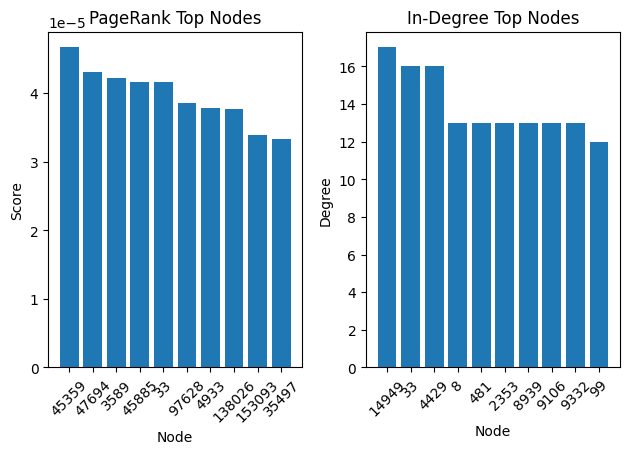

In [ ]:
import matplotlib.pyplot as plt

# top 10 PageRank
pr_nodes = [node for node, _ in top_pr]
pr_scores_vals = [score for _, score in top_pr]

# top 10 in-degree
in_nodes = [node for node, _ in top_in_degree]
in_scores_vals = [score for _, score in top_in_degree]

# create side-by-side plots
plt.figure()

# PageRank subplot
plt.subplot(1, 2, 1)
plt.bar(range(len(pr_nodes)), pr_scores_vals)
plt.xticks(range(len(pr_nodes)), pr_nodes, rotation=45)
plt.title("PageRank Top Nodes")
plt.xlabel("Node")
plt.ylabel("Score")

# In-degree subplot
plt.subplot(1, 2, 2)
plt.bar(range(len(in_nodes)), in_scores_vals)
plt.xticks(range(len(in_nodes)), in_nodes, rotation=45)
plt.title("In-Degree Top Nodes")
plt.xlabel("Node")
plt.ylabel("Degree")

plt.tight_layout()
plt.show()

Even though the exact nodes may change, the overall pattern remains similar. PageRank distributes importance based on network structure, while in-degree focuses only on connection counts.

## Runtime and Convergence Analysis

The PageRank algorithm shows a clear convergence pattern, where the difference between iterations decreases over time.


In [ ]:
import time

# measure how long PageRank takes on the sample graph
start_time = time.time()
pagerank(out_sample, in_sample, nodes_sample)
end_time = time.time()

print("Execution time (seconds):", end_time - start_time)

Iteration 1, diff = 0.499330833466961
Iteration 2, diff = 0.35234994120380075
Iteration 3, diff = 0.04989393706168392
Iteration 4, diff = 0.00833995627675124
Iteration 5, diff = 0.0026278222266636294
Iteration 6, diff = 0.0015934266673884832
Iteration 7, diff = 0.0012647046132031148
Iteration 8, diff = 0.0010141230979691593
Iteration 9, diff = 0.0008401023431439635
Iteration 10, diff = 0.0006996676257808179
Iteration 11, diff = 0.0005877567434004524
Iteration 12, diff = 0.0004938099611399534
Iteration 13, diff = 0.0004173102273177177
Iteration 14, diff = 0.00035251705619819833
Iteration 15, diff = 0.0002988732038452481
Iteration 16, diff = 0.00025327873811283546
Iteration 17, diff = 0.00021485347458793371
Iteration 18, diff = 0.00018238611172255825
Iteration 19, diff = 0.00015489804614302857
Iteration 20, diff = 0.0001315263952855667
Iteration 21, diff = 0.00011174244937468594
Iteration 22, diff = 9.494839986179363e-05
Iteration 23, diff = 8.068108075555952e-05
Iteration 24, diff = 6.8

The exact execution time may vary slightly depending on the system and the sampled graph, but it remains relatively fast for the sampled dataset.

## Discussion of Results

The results show that PageRank and in-degree centrality do not always produce the same rankings. While there is some overlap, PageRank considers the importance of connections rather than just the number of them.
Because the sampled graph changes each run, the exact rankings may differ, but the overall behavior and conclusions remain consistent.

## Conclusion

PageRank provides a more meaningful measure of influence in the network compared to simple connection counts. Even though the sampled graph introduces some variation in results, the overall patterns stay consistent. The algorithm converges reliably and can be applied to larger datasets, as shown by running it on the full network.


## Running on Full Dataset (Optional)

To verify that our implementation works on larger graphs, we also run PageRank once on the full dataset. This is not used for detailed analysis, but to confirm that the algorithm behaves correctly on the complete network.

In [ ]:
import time

# run PageRank on full dataset and measure time
start_time = time.time()

pr_full = pagerank(out_edges, in_edges, nodes, max_iter=100)

end_time = time.time()

print("Full dataset execution time (seconds):", end_time - start_time)

Iteration 1, diff = 0.526650134230663
Iteration 2, diff = 0.20833341200547348
Iteration 3, diff = 0.09980923588333969
Iteration 4, diff = 0.058725832608101575
Iteration 5, diff = 0.038112046356322135
Iteration 6, diff = 0.026186396347465894
Iteration 7, diff = 0.01864300844061469
Iteration 8, diff = 0.01361305125361749
Iteration 9, diff = 0.010122612184629816
Iteration 10, diff = 0.0076397733058942005
Iteration 11, diff = 0.0058374242346570975
Iteration 12, diff = 0.0045090372809830324
Iteration 13, diff = 0.003516800243095046
Iteration 14, diff = 0.0027656391542313073
Iteration 15, diff = 0.0021865022174099233
Iteration 16, diff = 0.0017373474664436502
Iteration 17, diff = 0.0013863600903377847
Iteration 18, diff = 0.0011102303894679057
Iteration 19, diff = 0.0008915660726356821
Iteration 20, diff = 0.0007179131833811791
Iteration 21, diff = 0.0005796810042479842
Iteration 22, diff = 0.0004691560484138681
Iteration 23, diff = 0.00038046119569267974
Iteration 24, diff = 0.0003090953720

In [ ]:
# check sum of ranks
print("Sum of PageRank values:", sum(pr_full.values()))

# top nodes
top_full = sorted(pr_full.items(), key=lambda x: x[1], reverse=True)[:10]

print("Top nodes (full dataset):")
for node, score in top_full:
    print(f"{node:<6} -> {score}")

Sum of PageRank values: 0.9405565941756014
Top nodes (full dataset):
33     -> 0.0010696923082972412
93     -> 0.0009509533153039218
8      -> 0.0008522777797385718
2501   -> 0.0007887507646564433
94     -> 0.0007775697197293747
4429   -> 0.0007360630647207549
56     -> 0.0006740966773523773
95     -> 0.0006646513074487256
151    -> 0.0006404912323446361
2353   -> 0.0006197503052176897


The algorithm shows similar convergence behavior, where the difference between iterations steadily decreases. The execution time is significantly higher compared to the sampled graph due to the size of the dataset.
The top-ranked nodes and score distribution follow similar patterns, confirming that the implementation scales and behaves consistently on larger graphs.
